In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


LIBRARIES

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

INPUTS

In [3]:
IMG_HEIGHT=224
IMG_WIDTH=224
IMG_CHANNELS = 3
CLASS_NAMES =["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [4]:
transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir = "/content/drive/MyDrive/flower_images/train"
val_dir = "/content/drive/MyDrive/flower_images/val"

train_data = datasets.ImageFolder(root=train_dir, transform=transform)
val_data= datasets.ImageFolder(root=val_dir, transform=val_transform)

train_dataset = DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset = DataLoader(val_data, batch_size=16)

NETWORK ARCHITECTURE

In [5]:
class DSConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.DConv2d = nn.Conv2d(in_ch, in_ch, kernel_size= 3, stride=stride, padding=1, groups=in_ch)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.relu = nn.ReLU(inplace=True)
        self.PConv2d =  nn.Conv2d(in_ch, out_ch, kernel_size =1)
        self.bn2 = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x = self.relu(self.bn1(self.DConv2d(x)))
        out = self.relu(self.bn2(self.PConv2d(x)))

        return out


In [6]:
model = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, kernel_size= 3, stride=2, padding=1),

    DSConv2d(32, 64, 1),
    DSConv2d(64, 128, 2),
    DSConv2d(128, 128, 1),
    DSConv2d(128, 256, 2),
    DSConv2d(256, 256, 1),
    DSConv2d(256, 512, 2),
    DSConv2d(512, 512, 1),
    DSConv2d(512, 1024, 2),
    nn.AvgPool2d(kernel_size = 7),
    nn.Flatten(),
    nn.Linear(1024, len(CLASS_NAMES))
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

TRAINING

In [8]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss =[]
    train_acc =[]
    val_loss =[]
    val_acc =[]
    for epoch in range(epochs):
        model.train()
        correct_preds=0
        total_loss =0
        total_samples= 0
        for images, labels in train_loader:
            images, labels= images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct_preds += (preds==labels).sum().item()
            total_loss +=loss.item()
            total_samples += labels.size(0)
        acc = correct_preds/total_samples
        print(f"Epoch {epoch+1}: Loss: {total_loss:.4f}, Training Accuracy:{acc:.4f}")
        train_loss.append(total_loss)
        train_acc.append(acc)

        model.eval()
        with torch.no_grad():
            eval_loss =0
            eval_preds=0
            eval_samples =0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                eval_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                eval_preds += (preds==labels).sum().item()
                eval_samples += labels.size(0)
            eval_acc = eval_preds/eval_samples
            print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")
            val_loss.append(eval_loss)
            val_acc.append(eval_acc)
    return train_loss, train_acc, val_loss, val_acc

In [9]:
EPOCHS = 10
train_loss, train_acc, val_loss, val_acc= train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss: 227.2957, Training Accuracy:0.5193
Validation Loss: 60.1096, Validation Accuracy: 0.6490
Epoch 2: Loss: 190.4566, Training Accuracy:0.6103
Validation Loss: 61.7161, Validation Accuracy: 0.6460
Epoch 3: Loss: 169.2470, Training Accuracy:0.6580
Validation Loss: 49.9324, Validation Accuracy: 0.7020
Epoch 4: Loss: 153.6901, Training Accuracy:0.6890
Validation Loss: 65.5653, Validation Accuracy: 0.6660
Epoch 5: Loss: 132.9935, Training Accuracy:0.7347
Validation Loss: 49.9787, Validation Accuracy: 0.6990
Epoch 6: Loss: 130.7969, Training Accuracy:0.7410
Validation Loss: 47.1688, Validation Accuracy: 0.7510
Epoch 7: Loss: 106.3191, Training Accuracy:0.7943
Validation Loss: 48.6785, Validation Accuracy: 0.7330
Epoch 8: Loss: 99.2716, Training Accuracy:0.8077
Validation Loss: 47.2132, Validation Accuracy: 0.7540
Epoch 9: Loss: 86.2989, Training Accuracy:0.8300
Validation Loss: 44.9504, Validation Accuracy: 0.7890
Epoch 10: Loss: 81.8299, Training Accuracy:0.8430
Validation Loss:

PLOTTING

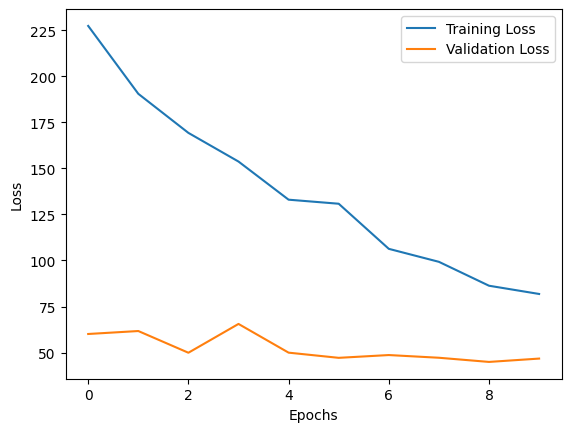

In [10]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

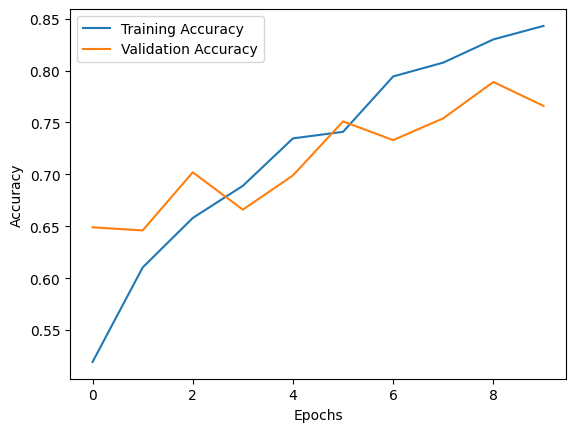

In [11]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()